In [7]:
import os
from dotenv import load_dotenv

# 1. 현재 디렉터리의 .env 파일을 시스템 환경변수로 로드합니다.
load_dotenv("D:\code\work_space\Instant Ticket\Personal_Information.env")

# 2. os.getenv()를 통해 환경변수 값을 가져옵니다.
db_host = os.getenv("DB_HOST")
db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")
api_key = os.getenv("API_KEY")

# 3. 코드 내에서 사용 (예시 출력)
print(f"접속 호스트: {db_host}")
print(f"사용자 계정: {db_user}")
# 실무에서는 비밀번호나 API 키를 화면에 그냥 출력하지 않도록 주의하십시오.
print(f"비밀번호 로드 성공 여부: {db_password}")
print(db_host)

ModuleNotFoundError: No module named 'dotenv'

In [ ]:
import pyautogui

# 마우스 왼쪽 버튼 클릭
pyautogui.click()

# 키보드로 문자열 타이핑 (각 글자마다 0.1초 딜레이)
pyautogui.write('Hello, world!', interval=0.1)

# 키보드 누르기
pyautogui.press('enter')

In [16]:
import subprocess
import pyautogui
import time

chrome_path = "C:\\Program Files\\Google\\Chrome\\Application\\chrome.exe"
url = "https://www.ticketlink.co.kr/sports"

# 새 창으로 크롬 실행
subprocess.Popen([chrome_path, "--new-window", url])

# 2. 창이 열리고 화면에 뜰 때까지 잠시 대기 (컴퓨터 속도에 따라 1~2초 조절)
time.sleep(1.5)

# 3. 윈도우 키 + 위쪽 방향키를 눌러 현재 활성화된(새로 뜬) 창을 최대화
pyautogui.hotkey('win', 'up')


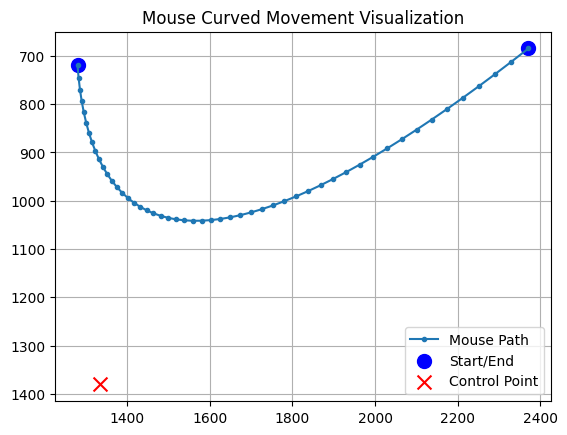

In [ ]:
import matplotlib.pyplot as plt
import random

# 가상의 시작점과 도착점
start_x, start_y = pyautogui.position()

screen_width, screen_height = pyautogui.size()
target_x = screen_width * 0.5
target_y = screen_height * 0.5

# 제어점 생성 (곡선의 휘어짐을 결정)
cp_x = (start_x + target_x) / 2 + random.randint(-800, 800)
cp_y = (start_y + target_y) / 2 + random.randint(-800, 800)

x_coords = []
y_coords = []

# 좌표 계산
steps = 50
for i in range(steps + 1):
    t = i / steps
    current_x = ((1 - t) ** 2) * start_x + 2 * (1 - t) * t * cp_x + (t ** 2) * target_x
    current_y = ((1 - t) ** 2) * start_y + 2 * (1 - t) * t * cp_y + (t ** 2) * target_y
    x_coords.append(current_x)
    y_coords.append(current_y)

# 시각화(그래프 그리기)
plt.plot(x_coords, y_coords, marker='.', label='Mouse Path') # 이동 경로
plt.scatter([start_x, target_x], [start_y, target_y], color='blue', s=100, label='Start/End') # 시작/끝점
plt.scatter([cp_x], [cp_y], color='red', marker='x', s=100, label='Control Point') # 제어점

plt.gca().invert_yaxis() # 모니터는 아래로 갈수록 y좌표가 증가하므로 y축을 뒤집음
plt.legend()
plt.title("Mouse Curved Movement Visualization")
plt.grid(True)
plt.show()

In [ ]:
import torch
from PIL import Image
from torchvision import transforms

# 1. PyTorch Hub를 통해 사전 학습된 PARSeq 모델 불러오기
# 처음 실행 시 모델 파일을 다운로드하므로 시간이 조금 걸립니다.
print("PARSeq 모델을 불러오는 중...")
parseq = torch.hub.load('baudm/parseq', 'parseq', pretrained=True).eval()

# 2. 이미지 전처리 설정 (PARSeq가 요구하는 고정 사이즈: 32x128)
img_transform = transforms.Compose([
    transforms.Resize((32, 128), transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5) # 정규화
])

# 3. 테스트할 이미지 불러오기 및 변환
image_path = r"C:\Users\lijih\Desktop\qwer\CAPTCHA_30.png" # 테스트할 일반 텍스트 이미지 경로
img = Image.open(image_path).convert('RGB')
img_tensor = img_transform(img).unsqueeze(0) # 배치 차원 추가

# 4. 이미지 텍스트 판독 (추론)
print("텍스트 인식 진행 중...")
with torch.inference_mode():
    logits = parseq(img_tensor)
    pred = logits.softmax(-1)
    label, certainty = parseq.tokenizer.decode(pred)

print(f"✅ 최종 인식 결과: {label[0]}")

PARSeq 모델을 불러오는 중...


Using cache found in C:\Users\lijih/.cache\torch\hub\baudm_parseq_main
d:\code\Ticket-buying-bot\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\code\Ticket-buying-bot\lib\site-packages\timm\models\helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Downloading: "https://github.com/baudm/parseq/releases/download/v1.0.0/parseq-bb5792a6.pt" to C:\Users\lijih/.cache\torch\hub\checkpoints\parseq-bb5792a6.pt


100.0%


텍스트 인식 진행 중...
✅ 최종 인식 결과: VRISM


In [8]:
# 마우스 동작 제어(곡전)
import pyautogui
import time
import random

pyautogui.PAUSE = 0

def move_mouse_curved_fast(end_x, end_y, duration=0.1):
    start_x, start_y = pyautogui.position()

    # 화면 비율 계산
    screen_width, screen_height = pyautogui.size()
    target_x = screen_width * end_x
    target_y = screen_height * end_y
    
    # 제어점 생성
    cp_x = (start_x + target_x) / 2 + random.randint(-800, 800)
    cp_y = (start_y + target_y) / 2 + random.randint(-800, 800)

    # 시작 시간 기록 
    start_time = time.perf_counter()
    
    # 설정한 duration(시간)이 다 끝날 때까지 무한 반복
    while True:
        current_time = time.perf_counter()
        elapsed_time = current_time - start_time
        
        # 전체 목표 시간 중 현재 몇 % 진행되었는지 계산 (0.0 ~ 1.0)
        t = elapsed_time / duration
        
        # t가 1.0을 넘어가면(목표 시간 초과) 1.0으로 고정하고 반복문 종료 준비
        if t >= 1.0:
            t = 1.0
            
        # 2차 베지어 곡선 공식 (time.sleep 없이 진행률 t에 따라 위치 계산)
        current_x = int(((1 - t) ** 2) * start_x + 2 * (1 - t) * t * cp_x + (t ** 2) * target_x)
        current_y = int(((1 - t) ** 2) * start_y + 2 * (1 - t) * t * cp_y + (t ** 2) * target_y)

        # 0초로 설정하여 렉 없이 이동
        pyautogui.moveTo(current_x, current_y, duration=0)
        
        # 목표 지점에 도착했으면 무한 반복 탈출
        if t >= 1.0:
            break

# 사용 예시: 화면 정중앙(0.5, 0.5)으로 0.2초 만에 아주 빠르고 부드럽게 곡선 이동
#move_mouse_curved_fast(0.278, 0.22, duration=0.9)

In [9]:
#마우스 동작 제어(직각)
import pyautogui
import math
import time
import random

def move_right_angle_ratio(end_x, end_y, speed_pixels_per_sec=1000, x_first=None):
    # 1. 현재(출발) 위치 가져오기
    start_x, start_y = pyautogui.position()
    
    # 화면 비율에 맞게 '실제 이동할 픽셀 좌표' 계산
    screen_width, screen_height = pyautogui.size()
    target_x = screen_width * end_x
    target_y = screen_height * end_y
    
    # 2. 어떤 축을 먼저 이동할지 결정
    if x_first is None:
        x_first = random.choice([True, False])
        
    # 3. 선택된 방향에 따라 '경유지(Corner)' 좌표 설정
    if x_first:
        # X축 먼저 이동 (가로 -> 세로)
        corner_x = target_x
        corner_y = start_y
        
    else:
        # Y축 먼저 이동 (세로 -> 가로)
        corner_x = start_x
        corner_y = target_y
    
    # 4. 각 구간의 실제 이동 거리 계산 (어느 방향이든 안전하게 거리 계산)
    dist_1 = math.hypot(corner_x - start_x, corner_y - start_y)   # 출발지 -> 경유지
    dist_2 = math.hypot(target_x - corner_x, target_y - corner_y) # 경유지 -> 도착지
    
    # 5. 거리에 비례하여 이동 시간(duration) 할당
    duration_1 = dist_1 / speed_pixels_per_sec
    duration_2 = dist_2 / speed_pixels_per_sec
    
    # 6. 직각 이동 실행
    pyautogui.moveTo(corner_x, corner_y, duration=duration_1) # 1단계 이동
    
    # [수정된 부분] 비율(end_x, y)이 아니라 픽셀(target_x, y)로 이동!
    pyautogui.moveTo(target_x, target_y, duration=duration_2) # 2단계 이동


In [10]:
#보안 문자 캡처
import pyautogui
import time
import os  

def screenshot_by_ratio(save_path, filename, start_x_ratio, start_y_ratio, width_ratio, height_ratio):
    # 1. 화면 비율 계산 (이전과 동일)
    screen_width, screen_height = pyautogui.size()
    start_x = int(screen_width * start_x_ratio)
    start_y = int(screen_height * start_y_ratio)
    capture_width = int(screen_width * width_ratio)
    capture_height = int(screen_height * height_ratio)
    
    # 2. 지정한 폴더가 컴퓨터에 없으면 자동으로 생성
    # exist_ok=True 옵션을 넣으면 이미 폴더가 있어도 에러가 나지 않습니다.
    os.makedirs(save_path, exist_ok=True)
    
    # 3. 폴더 경로와 파일 이름을 안전하게 합치기
    full_file_path = os.path.join(save_path, filename)
    
    # 4. 합쳐진 전체 경로(full_file_path)로 스크린샷 저장
    pyautogui.screenshot(full_file_path, region=(start_x, start_y, capture_width, capture_height))

In [14]:
#창 로드
def  load_win():
    chrome_path = "C:\\Program Files\\Google\\Chrome\\Application\\chrome.exe"
    url = "https://www.ticketlink.co.kr/sports"
    
    # 새 창으로 크롬 실행
    subprocess.Popen([chrome_path, "--new-window", url])
    
    # 2. 창이 열리고 화면에 뜰 때까지 잠시 대기 (컴퓨터 속도에 따라 1~2초 조절)
    time.sleep(1.5)
    
    # 3. 윈도우 키 + 위쪽 방향키를 눌러 현재 활성화된(새로 뜬) 창을 최대화
    pyautogui.hotkey('win', 'up')

In [12]:
#보안 문자
import torch
from PIL import Image
from torchvision import transforms

parseq = torch.hub.load('baudm/parseq', 'parseq', pretrained=True).eval()

def chptcha(img_path=r"D:\code\work_space\Instant Ticket\screenshot\CAPTCHA.png"):
    img_transform = transforms.Compose([
        transforms.Resize((32, 128), transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(0.5, 0.5) # 정규화
    ])
    
    # 3. 테스트할 이미지 불러오기 및 변환
    img = Image.open(img_path).convert('RGB')
    img_tensor = img_transform(img).unsqueeze(0) # 배치 차원 추가
    
    # 4. 이미지 텍스트 판독 (추론)
    with torch.inference_mode():
        logits = parseq(img_tensor)
        pred = logits.softmax(-1)
        label, certainty = parseq.tokenizer.decode(pred)
    
    return label[0]

Using cache found in C:\Users\lijih/.cache\torch\hub\baudm_parseq_main


In [ ]:
#로그인
load_win()
time.sleep(0.5)
move_mouse_curved_fast(0.56, 0.125, duration=random.gauss(1.5, 0.5))
pyautogui.click()
time.sleep(0.2)
move_mouse_curved_fast(random.uniform(0.02, 0.13), 0.48, duration=random.gauss(1.5, 0.5))
pyautogui.click()


In [ ]:
#티켓 구매 링크 이동(한화 이글스 기준)
move_mouse_curved_fast(0.28, 0.22, duration=0.5)
pyautogui.click()

move_right_angle_ratio(0.36, 0.29, x_first=False)
pyautogui.click()

time.sleep(0.5)

move_mouse_curved_fast(0.68, 0.9, duration=0.5)
pyautogui.click()

move_mouse_curved_fast(0.547, 0.64, duration=0.5)
pyautogui.click()

In [ ]:
#보안 문자 캡처
save_path = r"D:\code\work_space\Instant Ticket\screenshot"
screenshot_by_ratio(save_path, "CAPTCHA.png", 0.145, 0.32, 0.103, 0.067)

In [ ]:
#보안 문자 입력
move_mouse_curved_fast(0.18, 0.41, duration=0.5)
pyautogui.click()

A = chptcha()
print(A)

pyautogui.write(A, interval=0.1)

move_mouse_curved_fast(0.23, 0.48, duration=0.5)
pyautogui.click()

COC


NameError: name 'pyautogui' is not defined

In [15]:
load_win()

NameError: name 'subprocess' is not defined

In [ ]:
import time
from datetime import datetime

# 목표 시간 설정 (예: 2026년 8월 1일 오후 3시 30분 0초)
target_time = datetime(2026, 8, 1, 4, 0, 0)

print(f"목표 시간인 {target_time}까지 대기 중...")

while True:
    now = datetime.now()
    if now >= target_time:
        print("🚀 목표 시간이 되었습니다! 동작 시작!")
        save_path = r"D:\code\work_space\Instant Ticket\screenshot"
        screenshot_by_ratio(save_path, "CAPTCHA.png", 0.145, 0.32, 0.103, 0.067)
        move_mouse_curved_fast(0.18, 0.41, duration=0.5)
        pyautogui.click()
        
        A = chptcha()
        print(A)
        
        pyautogui.write(A, interval=0.1)
        
        move_mouse_curved_fast(0.23, 0.48, duration=0.5)
        pyautogui.click()
        break
    
    # 1초마다 현재 시간을 체크 (CPU 부하를 줄이기 위함)
    time.sleep(1)

목표 시간인 2026-08-01 03:59:00까지 대기 중...
🚀 목표 시간이 되었습니다! 동작 시작!
SMIWV
